In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("/Users/esra/Desktop/visualization/02_activities/assignments/Intimate Partner and Family Violence.csv")
print("Rows:", len(df))
print("Columns:", df.columns.tolist())
print(df.head())

Rows: 190723
Columns: ['_id', 'INDEX_', 'REPORT_YEAR', 'REPORT_MONTH', 'REPORT_DOW', 'HISTORICAL', 'FAMILY_VIOLENCE_FLAG', 'FAMILY_VIOLENCE_RELATION', 'DIVISION', 'PREMISES_TYPE', 'HOOD_158', 'NEIGHBOURHOOD_158', 'HOOD_140', 'NEIGHBOURHOOD_140', 'COUNT_']
   _id  INDEX_  REPORT_YEAR REPORT_MONTH REPORT_DOW      HISTORICAL  \
0    1       1         2024         July     Monday  Not Historical   
1    2       2         2024     February    Tuesday  Not Historical   
2    3       3         2024     February    Tuesday  Not Historical   
3    4       4         2024     February    Tuesday  Not Historical   
4    5       5         2024     February    Tuesday  Not Historical   

  FAMILY_VIOLENCE_FLAG      FAMILY_VIOLENCE_RELATION DIVISION PREMISES_TYPE  \
0             Intimate  Former Intimate Relationship      D33       Outside   
1             Intimate  Former Intimate Relationship      D14         Other   
2             Intimate         Intimate Relationship      D32         House   
3

In [14]:
df["year_month"] = pd.to_datetime(
    df["REPORT_YEAR"].astype(str) + "-" + df["REPORT_MONTH"].astype(str),
    format="%Y-%B",
    errors="coerce"
)
df = df.dropna(subset=["year_month"])

In [15]:
monthly = (
    df.groupby(["year_month", "FAMILY_VIOLENCE_FLAG"])["COUNT_"]
      .sum()
      .reset_index()
)

In [16]:
print(type(monthly))
print(monthly.head())

<class 'pandas.core.frame.DataFrame'>
  year_month FAMILY_VIOLENCE_FLAG  COUNT_
0 2014-01-01               Family     174
1 2014-01-01             Intimate    1416
2 2014-01-01         Unclassified      43
3 2014-02-01               Family     168
4 2014-02-01             Intimate    1390


['Family' 'Intimate']


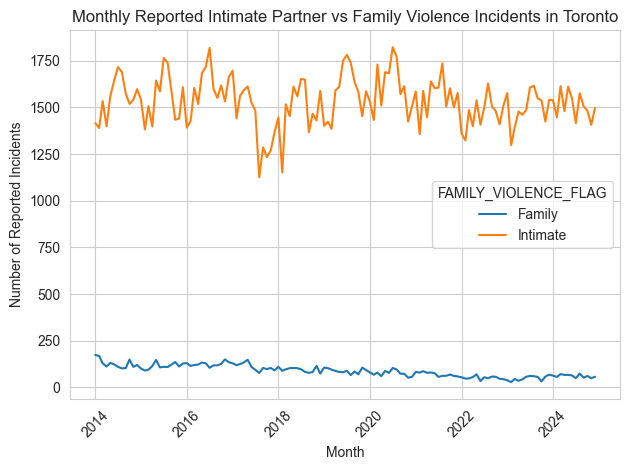

In [26]:
df = df[df["FAMILY_VIOLENCE_FLAG"].isin(["Intimate", "Family"])]

monthly = (
    df.groupby(["year_month", "FAMILY_VIOLENCE_FLAG"])["COUNT_"]
      .sum()
      .reset_index()
).sort_values("year_month")

print(monthly["FAMILY_VIOLENCE_FLAG"].unique())
sns.set_style("whitegrid")

ax = sns.lineplot(
    data=monthly,
    x="year_month",
    y="COUNT_",
    hue="FAMILY_VIOLENCE_FLAG"
)

ax.set_title("Monthly Reported Intimate Partner vs Family Violence Incidents in Toronto")
ax.set_xlabel("Month")
ax.set_ylabel("Number of Reported Incidents")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



In [27]:
df = df[df["FAMILY_VIOLENCE_FLAG"].isin(["Intimate", "Family"])]

monthly = (
    df.groupby(["year_month", "FAMILY_VIOLENCE_FLAG"])["COUNT_"]
      .sum()
      .reset_index()
).sort_values("year_month")


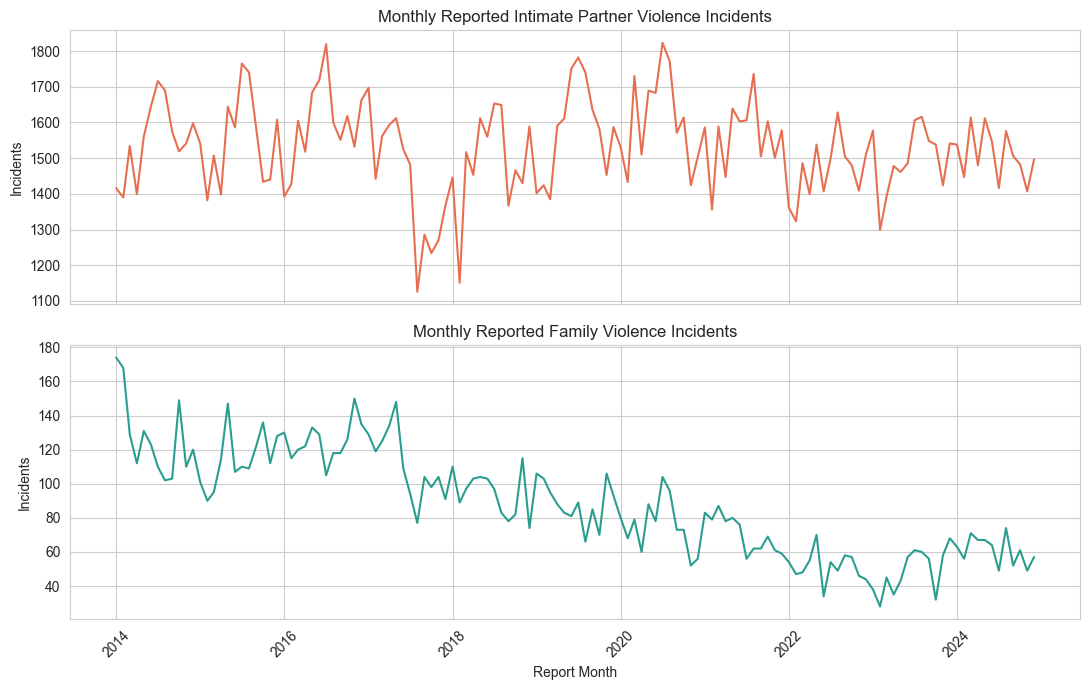

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

# Intimate Partner Violence
sns.lineplot(
    data=monthly[monthly["FAMILY_VIOLENCE_FLAG"] == "Intimate"],
    x="year_month",
    y="COUNT_",
    ax=axes[0],
    color="#E76F51"
)
axes[0].set_title("Monthly Reported Intimate Partner Violence Incidents")
axes[0].set_ylabel("Incidents")

# Family Violence
sns.lineplot(
    data=monthly[monthly["FAMILY_VIOLENCE_FLAG"] == "Family"],
    x="year_month",
    y="COUNT_",
    ax=axes[1],
    color="#2A9D8F"
)
axes[1].set_title("Monthly Reported Family Violence Incidents")
axes[1].set_ylabel("Incidents")
axes[1].set_xlabel("Report Month")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


 >What software did you use to create your data visualization?
# I created this visualization using Python, specifically using the libraries pandas for data preparation and seaborn/matplotlib for visualization. This environment allowed me to document every step of the workflow, from data cleaning and transformation to the final chart design.
    > Who is your intended audience? 
# The intended audience includes students, researchers, policymakers, and community advocates interested in understanding trends in reported intimate partner and family violence in Toronto. The visualization is designed for viewers with general data literacy rather than technical expertise, prioritizing clarity over advanced statistical representation.  
    > What information or message are you trying to convey with your visualization? 
# The visualization shows monthly trends over time for two related but differently scaled categories of violence: intimate partner violence and other family violence. The main message is that while intimate partner violence incidents are consistently much higher in magnitude, family violence exhibits its own distinct trend over time that would be difficult to see if plotted on the same axis. 
    > What aspects of design did you consider when making your visualization? How did you apply them? With what elements of your plots? 
# Several design principles guided the visualization such as scale and comparability because the two categories differ greatly in magnitude, I separated them into aligned subplots (small multiples). This avoids scale distortion and improves trend visibility. The other thing I considered is the cognitive load which I did by removing overlapping lines and markers reduces visual clutter and makes patterns easier to interpret. To help with comparability I used plots for both categories to share the same time axis to preserve temporal comparability.
    > How did you ensure that your data visualizations are reproducible? If the tool you used to make your data visualization is not reproducible, how will this impact your data visualization? 
# The visualization is fully reproducible because it was created using a script-based workflow in Python. All data transformations (date parsing, filtering, aggregation) and visualization steps are recorded in the notebook. This allows others to rerun the analysis using the same dataset.
    > How did you ensure that your data visualization is accessible?  
# Accessibility was a central consideration in the design of this visualization. I used clear, descriptive titles and axis labels so viewers can understand the content without needing prior knowledge of the dataset. To improve readability, I avoided clutter and overlapping visual elements, which can make charts difficult to interpret, especially for audiences with lower visual literacy. Color was used as a supplementary cue rather than the sole method of distinction, ensuring that the visualization remains interpretable even for viewers with color vision deficiencies. You see that I tried different visuals first but I found them hard to read and tried new tools to make it more easy to read. Finally, I separated the two data series into aligned plots to prevent misinterpretation caused by large differences in scale. 
    > Who are the individuals and communities who might be impacted by your visualization?  
 # This visualization represents reported incidents of violence, so the communities affected include survivors of intimate partner and family violence, social service providers, policymakers, and advocacy organizations. Presenting aggregate trends rather than individual-level data helps avoid stigmatization while still highlighting patterns relevant to public awareness and policy planning.   
    > How did you choose which features of your chosen dataset to include or exclude from your visualization? 
# The Tableau visual focused on location and the number incidents. For this one I wanted to focus on time (monthly trends) and type of violence classification because these variables directly support the question of how patterns differ between intimate partner and family violence. This also make the visual distinct from the first one.
    > What ‘underwater labour’ contributed to your final data visualization product?
# A substantial amount of unseen work contributed to the final visualization. This included cleaning and formatting the dataset to ensure consistency, converting date fields into proper datetime objects for accurate temporal analysis, and aggregating incident counts at the monthly level to make trends visible. I also spent time debugging plotting errors and resolving file path issues that affected the workflow. Beyond technical fixes, the visualization went through iterations after identifying problems with scale and visual clutter in the initial version. Although this labour is not visible in the finished chart, it is essential for producing a visualization that is accurate, ethically responsible, and easy to interpret.